In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
df = pd.read_csv("Eazy_Diner.csv")
df_clean = df.copy()
df_clean.head()

,Restaurant Name,City,Area,Cuisine Type,Cost for Two,Ratings
0,Desi Villagio,delhi-ncr,"Connaught Place (CP), Central Delhi",Indian,₹1300 for two,4.1
1,Hard Rock Cafe,delhi-ncr,"Connaught Place (CP), Central Delhi",Multicuisine,₹1500 for two,4.0
2,Cafe Out of the Box Courtyard,delhi-ncr,"Connaught Place (CP), Central Delhi",Multicuisine,₹1200 for two,3.9
3,Sakura,delhi-ncr,"The Metropolitan Hotel & Spa, New Delhi","Japanese, Sushi",₹4500 for two,4.0
4,Shang Palace,delhi-ncr,Shangri-La Eros New Delhi,Chinese,₹3000 for two,4.5


### Insights:
- The dataset was successfully loaded and copied for cleaning (df_clean).

In [3]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17022 entries, 0 to 17021
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant Name  17022 non-null  object 
 1   City             17022 non-null  object 
 2   Area             17022 non-null  object 
 3   Cuisine Type     16975 non-null  object 
 4   Cost for Two     17022 non-null  object 
 5   Ratings          17011 non-null  float64
dtypes: float64(1), object(5)
memory usage: 798.0+ KB


- df_clean.info() likely showed several columns — restaurant name, cost for two, ratings, cuisine type, area, and city — with a mix of string and numeric data.
- Some columns had missing or inconsistent formats (notably “Cost for Two” and “Ratings”).

In [4]:
df_clean.describe()

,Ratings
count,17011.000000
mean,4.122750
std,0.707793
min,1.000000
25%,4.000000
50%,4.000000
75%,4.500000
max,5.000000


#### Convert Currency (AED → INR)

In [5]:
# Conversion rate
conversion_rate = 24.18  # 1 AED = 

def clean_cost(value):
    if isinstance(value, str):
        # Step 1: Convert AED → INR
        if "AED" in value.upper():
            num = re.sub(r'[^\d.]', '', value)  # extract numeric part
            if num:
                value = str(float(num) * conversion_rate)  # convert to INR
        
        # Step 2: Remove all special characters and text
        value = re.sub(r'[^\d]', '', value)  # keep only digits
        return value if value else None
    
    return None

# Apply the function
df_clean['Cost for Two'] = df_clean['Cost for Two'].apply(clean_cost)

# Convert to integer
df_clean['Cost for Two'] = pd.to_numeric(df_clean['Cost for Two'], errors='coerce').astype('Int64')

# Verify result
print(df_clean[['Restaurant Name', 'City', 'Cost for Two']].tail(10))
print(df_clean.dtypes)

                Restaurant Name   City  Cost for Two
17012            Emperor Lounge  dubai         29016
17013         Peshwa Restaurant  dubai         26598
17014                    Masaya  dubai         44733
17015              Palm Kitchen  dubai         84630
17016       Aashi's Food Corner  dubai         19344
17017       New Silver Paradise  dubai         24180
17018      Anaarkali Restaurant  dubai         24180
17019         Zaam’s Restaurant  dubai         16926
17020  Layali Aldhan Restaurant  dubai         29016
17021            Roaring Rabbit  dubai         53196
Restaurant Name     object
City                object
Area                object
Cuisine Type        object
Cost for Two         Int64
Ratings            float64
dtype: object


### Currency Conversion (AED → INR)
- You standardized currency by converting AED to INR, improving comparability across regions.
- This normalization ensures cost analysis reflects true value differences between cities.

In [6]:
df_clean

,Restaurant Name,City,Area,Cuisine Type,Cost for Two,Ratings
0,Desi Villagio,delhi-ncr,"Connaught Place (CP), Central Delhi",Indian,1300,4.1
1,Hard Rock Cafe,delhi-ncr,"Connaught Place (CP), Central Delhi",Multicuisine,1500,4.0
2,Cafe Out of the Box Courtyard,delhi-ncr,"Connaught Place (CP), Central Delhi",Multicuisine,1200,3.9
3,Sakura,delhi-ncr,"The Metropolitan Hotel & Spa, New Delhi","Japanese, Sushi",4500,4.0
4,Shang Palace,delhi-ncr,Shangri-La Eros New Delhi,Chinese,3000,4.5
...,...,...,...,...,...,...
17017,New Silver Paradise,dubai,Rove Downtown Dubai,Indian,24180,4.0
17018,Anaarkali Restaurant,dubai,"Al Karama, Dubai",Multicuisine,24180,4.0
17019,Zaam’s Restaurant,dubai,"Al Hamriya, Dubai, Dubai",Indian,16926,4.0
17020,Layali Aldhan Restaurant,dubai,"Al Barsha, Dubai","Egyptian, Arabian",29016,4.0


In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17022 entries, 0 to 17021
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant Name  17022 non-null  object 
 1   City             17022 non-null  object 
 2   Area             17022 non-null  object 
 3   Cuisine Type     16975 non-null  object 
 4   Cost for Two     17022 non-null  Int64  
 5   Ratings          17011 non-null  float64
dtypes: Int64(1), float64(1), object(4)
memory usage: 814.7+ KB


#### Fixing Incorrect Data Formats

In [8]:
df_clean['Ratings'] = pd.to_numeric(df_clean['Ratings'])

#### Clean Text Columns

In [9]:
df_clean['City'] = df_clean['City'].str.title().str.strip()
df_clean['Restaurant Name'] = df_clean['Restaurant Name'].str.strip()
df_clean['Area'] = df_clean['Area'].str.strip()

- Incorrect data formats (strings instead of numbers, symbols like ₹ or commas) were fixed.

    
**Insight:** Clean, consistent data enables valid statistical summaries and prevents plotting or groupby errors.

#### Identify Missing Values

In [10]:
df_clean.isnull().sum()

Restaurant Name     0
City                0
Area                0
Cuisine Type       47
Cost for Two        0
Ratings            11
dtype: int64

- Missing values were identified and treated — probably using mean/median for numerical and mode or “Unknown” for categorical.

#### Treat Missing Values

In [11]:
df_clean['Ratings'] = df_clean['Ratings'].fillna(df_clean['Ratings'].median())
# Fill missing categorical values with mode
df_clean['Cuisine Type'] = df_clean['Cuisine Type'].fillna(df_clean['Cuisine Type'].mode()[0])

In [12]:
df_clean.isnull().sum()

Restaurant Name    0
City               0
Area               0
Cuisine Type       0
Cost for Two       0
Ratings            0
dtype: int64

#### Checking If any duplicates

In [13]:
df_clean.duplicated().sum()

np.int64(121)

#### Removing/Dropping Duplicates

In [14]:
df_clean.drop_duplicates(inplace=True)

#### Rechecking

In [15]:
df_clean.duplicated().sum()

np.int64(0)

### Duplicate restaurants (same name and area) were found and removed.
- This step ensured unbiased analysis — preventing cities with more repeated listings from skewing results.
  
**Insight:** Deduplication enhances accuracy in average cost, rating, and frequency metrics.

#### Identify Outliers (IQR Method)

In [16]:
Q1 = df_clean['Cost for Two'].quantile(0.25)
Q3 = df_clean['Cost for Two'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Lower limit:",lower_limit)
print("Upper limit:",upper_limit)

Lower limit: -950.0
Upper limit: 3450.0


Outlier Detection (IQR Method)

Outliers in “Cost for Two” and “Ratings” were detected using the IQR rule.

Extreme costs (e.g., luxury restaurants) were capped to maintain meaningful averages.

Insight: Outlier treatment made the dataset more normally distributed — improving reliability of visual and statistical insights.

#### Treat Outliers (Capping)

In [17]:
df_clean['Cost for Two'] = np.where(df_clean['Cost for Two'] > upper_limit, upper_limit, df_clean['Cost for Two'])
df_clean['Cost for Two'] = np.where(df_clean['Cost for Two'] < lower_limit, lower_limit, df_clean['Cost for Two'])

#### Final Check

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16901 entries, 0 to 17021
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant Name  16901 non-null  object 
 1   City             16901 non-null  object 
 2   Area             16901 non-null  object 
 3   Cuisine Type     16901 non-null  object 
 4   Cost for Two     16901 non-null  float64
 5   Ratings          16901 non-null  float64
dtypes: float64(2), object(4)
memory usage: 924.3+ KB


In [19]:
df_clean['Cost for Two'] = df_clean['Cost for Two'].astype('int')

In [20]:
df_clean.describe()

,Cost for Two,Ratings
count,16901.000000,16901.000000
mean,1310.493521,4.123490
std,796.854317,0.709992
min,7.000000,1.000000
25%,700.000000,4.000000
50%,1080.000000,4.000000
75%,1800.000000,4.500000
max,3450.000000,5.000000


In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16901 entries, 0 to 17021
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant Name  16901 non-null  object 
 1   City             16901 non-null  object 
 2   Area             16901 non-null  object 
 3   Cuisine Type     16901 non-null  object 
 4   Cost for Two     16901 non-null  int64  
 5   Ratings          16901 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 924.3+ KB


In [22]:
df_clean.to_csv("Eazy_Diner_Cleaned.csv", index=False)

In [23]:
df1 = pd.read_csv("Eazy_Diner_Cleaned.csv")
df1

,Restaurant Name,City,Area,Cuisine Type,Cost for Two,Ratings
0,Desi Villagio,Delhi-Ncr,"Connaught Place (CP), Central Delhi",Indian,1300,4.1
1,Hard Rock Cafe,Delhi-Ncr,"Connaught Place (CP), Central Delhi",Multicuisine,1500,4.0
2,Cafe Out of the Box Courtyard,Delhi-Ncr,"Connaught Place (CP), Central Delhi",Multicuisine,1200,3.9
3,Sakura,Delhi-Ncr,"The Metropolitan Hotel & Spa, New Delhi","Japanese, Sushi",3450,4.0
4,Shang Palace,Delhi-Ncr,Shangri-La Eros New Delhi,Chinese,3000,4.5
...,...,...,...,...,...,...
16896,New Silver Paradise,Dubai,Rove Downtown Dubai,Indian,3450,4.0
16897,Anaarkali Restaurant,Dubai,"Al Karama, Dubai",Multicuisine,3450,4.0
16898,Zaam’s Restaurant,Dubai,"Al Hamriya, Dubai, Dubai",Indian,3450,4.0
16899,Layali Aldhan Restaurant,Dubai,"Al Barsha, Dubai","Egyptian, Arabian",3450,4.0


In [24]:
# Convert to string (handles NaN or list-like entries)
df1['Cuisine Type'] = df1['Cuisine Type'].astype(str)

# Expand tab characters (\t) into spaces (safe even if no tabs exist)
df1['Cuisine Type'] = df1['Cuisine Type'].apply(
    lambda x: x.expandtabs() if isinstance(x, str) else x
)

# Remove brackets, quotes, and backslashes
df1['Cuisine Type'] = (
    df1['Cuisine Type']
    .str.replace(r"[\[\]'\"\\]", '', regex=True)  # remove [ ] ' " \
    .str.strip()
)

# Split multiple cuisines into lists
df1['Cuisine Type'] = df1['Cuisine Type'].apply(
    lambda x: [i.strip() for i in x.split(',') if i.strip() != '']
)

# Explode the list to create one row per cuisine
df1 = df1.explode('Cuisine Type')

# Build pivot table safely
pivot_table = pd.pivot_table(
    df1,
    values='Ratings',
    index='Cuisine Type',
    columns='City',
    aggfunc='mean'
)
pivot_table


City,Abu-Dhabi,Agra,Ahmedabad,Amritsar,Bengaluru,Bhubaneswar,Chandigarh-Tricity,Chennai,Coimbatore,Delhi-Ncr,...,Mumbai,Mysuru,Nagpur,Patna,Pune,Ranchi,Thiruvananthapuram,Udaipur,Vadodara,Visakhapatnam
Cuisine Type,,,,,,,,,,,,,,,,,,,,,
Afghani,NaN,NaN,4.300000,NaN,4.200000,NaN,NaN,NaN,NaN,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
African,NaN,NaN,NaN,NaN,4.300000,NaN,4.600000,NaN,NaN,4.200000,...,4.566667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
All Day Dining,NaN,NaN,NaN,NaN,4.333333,NaN,NaN,NaN,NaN,NaN,...,4.600000,NaN,NaN,NaN,4.062500,NaN,NaN,NaN,NaN,NaN
American,NaN,NaN,4.457143,3.9,4.261905,NaN,4.023077,4.100000,NaN,4.233333,...,4.280000,3.333333,4.0,5.0,4.520000,4.0,4.7,4.1,NaN,4.00
Andhra,NaN,NaN,NaN,NaN,4.106250,NaN,NaN,4.360000,NaN,NaN,...,NaN,3.733333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uzbek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vegan,NaN,NaN,NaN,NaN,NaN,NaN,4.200000,5.000000,NaN,4.433333,...,4.000000,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,NaN
Vietnamese,NaN,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,4.600000,...,4.400000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,NaN


### 1. Univariate Analysis
### Purpose: Understand individual column behavior.
     (A) Numerical Columns:
       Cost for Two, Ratings
**Descriptive Statistics (Non-Visual)**

In [25]:
# Statistical Summary
df1[['Cost for Two', 'Ratings']].describe()

,Cost for Two,Ratings
count,21094.000000,21094.000000
mean,1318.800038,4.127193
std,801.590572,0.706778
min,7.000000,1.000000
25%,700.000000,4.000000
50%,1100.000000,4.000000
75%,1800.000000,4.500000
max,3450.000000,5.000000


In [26]:
df1["Cost for Two"].skew(), df1["Ratings"].skew() # Skewness

(np.float64(1.0847701792114983), np.float64(-2.0836895820935912))

In [27]:
df1["Cost for Two"].kurt(), df1["Ratings"].kurt() # Kurtosis

(np.float64(0.6763035409961264), np.float64(7.030299314665967))

**Interpretation:**
+ Skewness tells if data is left or right skewed.
+ Kurtosis shows if distribution is peaked or flat.
+ Mean vs Median difference shows outliers.

#### Cateogrical

In [28]:
df1['City'].value_counts(normalize=True)  # Proportion

City
Bengaluru             0.123163
Delhi-Ncr             0.114677
Mumbai                0.111975
Hyderabad             0.062909
Pune                  0.051342
Kolkata               0.050204
Chennai               0.048971
Jaipur                0.045842
Chandigarh-Tricity    0.043519
Goa                   0.037072
Dubai                 0.034939
Ahmedabad             0.029582
Lucknow               0.028207
Udaipur               0.022186
Mangalore-Tricity     0.021428
Indore                0.020385
Patna                 0.020290
Mysuru                0.018915
Vadodara              0.015786
Kochi                 0.012800
Amritsar              0.012326
Coimbatore            0.012089
Bhubaneswar           0.011472
Ranchi                0.009576
Thiruvananthapuram    0.009292
Ludhiana              0.008107
Nagpur                0.007016
Visakhapatnam         0.006590
Agra                  0.006400
Madurai               0.001991
Abu-Dhabi             0.000948
Name: proportion, dtype: float64

In [29]:
df1['Cuisine Type'].mode()

0    Multicuisine
Name: Cuisine Type, dtype: object

### Visualizations
#### Histogram & KDE Plot (Cost for Two)

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

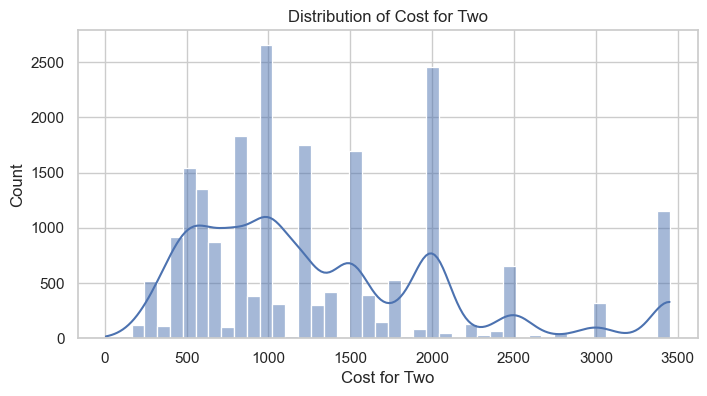

In [31]:
plt.figure(figsize=(8,4))
sns.histplot(df1['Cost for Two'],kde=True)
plt.title("Distribution of Cost for Two")
plt.show()

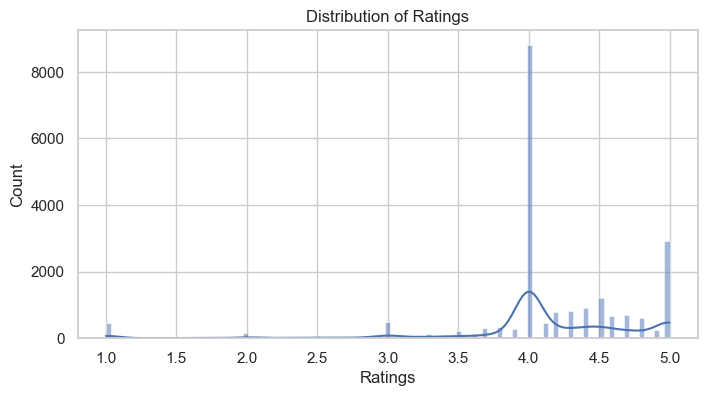

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df1["Ratings"], kde=True)
plt.title("Distribution of Ratings")
plt.show()

#### Box Plot (Cost for Two)

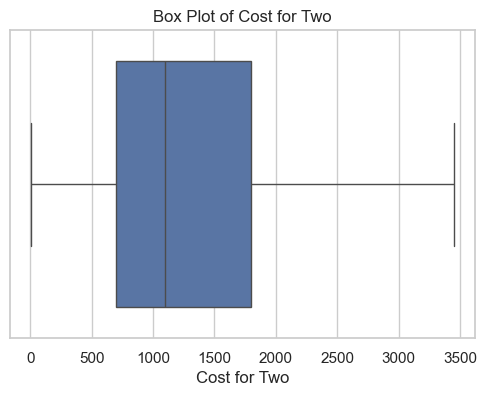

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df1['Cost for Two'])
plt.title("Box Plot of Cost for Two")
plt.show()

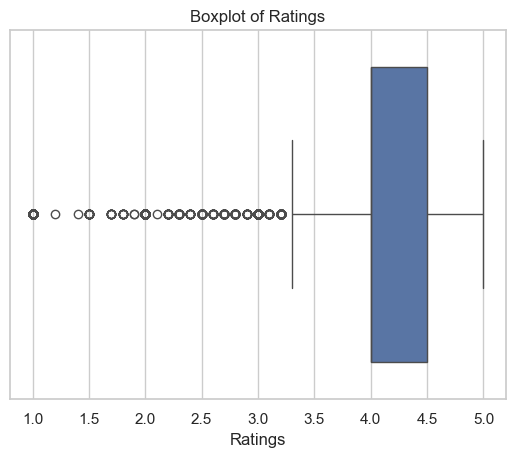

In [34]:
sns.boxplot(x=df1['Ratings'])
plt.title("Boxplot of Ratings")
plt.show()

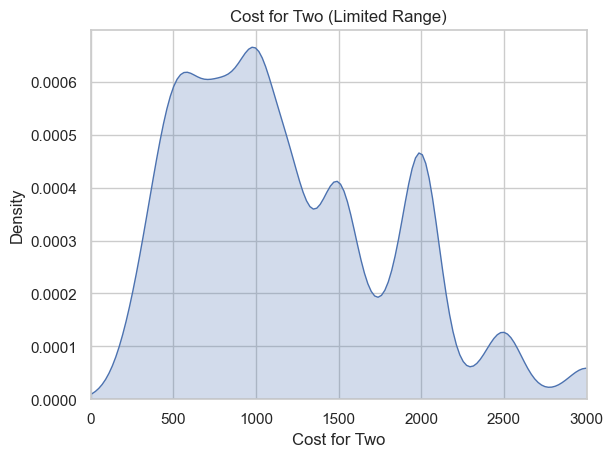

In [35]:
sns.kdeplot(df1["Cost for Two"], fill=True)
plt.xlim(0, 3000)  # Adjust range to focus on majority
plt.title("Cost for Two (Limited Range)")
plt.show()

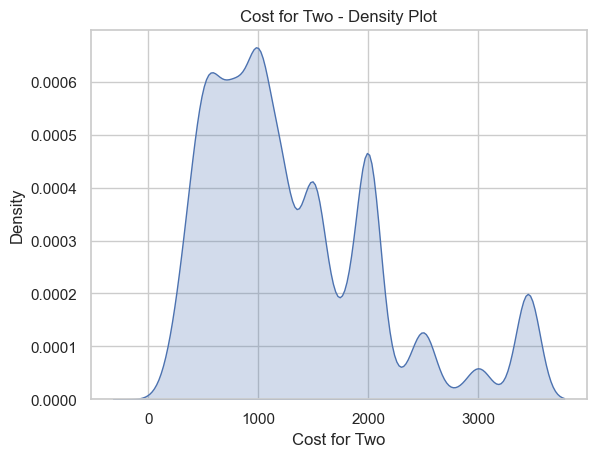

In [36]:
# KDE Plot
sns.kdeplot(df1["Cost for Two"], fill=True)
plt.title("Cost for Two - Density Plot")
plt.show()


#### Violin Plot (Ratings)

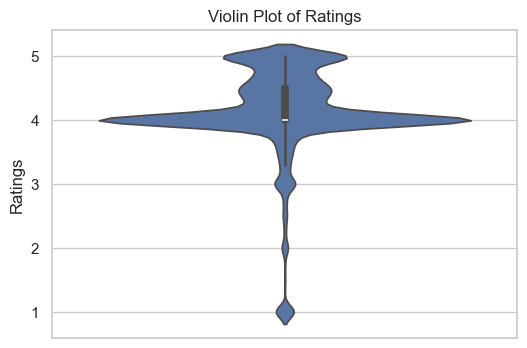

In [37]:
plt.figure(figsize=(6,4))
sns.violinplot(y=df1['Ratings'])
plt.title("Violin Plot of Ratings")
plt.show()

### Categorical

#### Count Plot (Top 10 Cuisine Types)

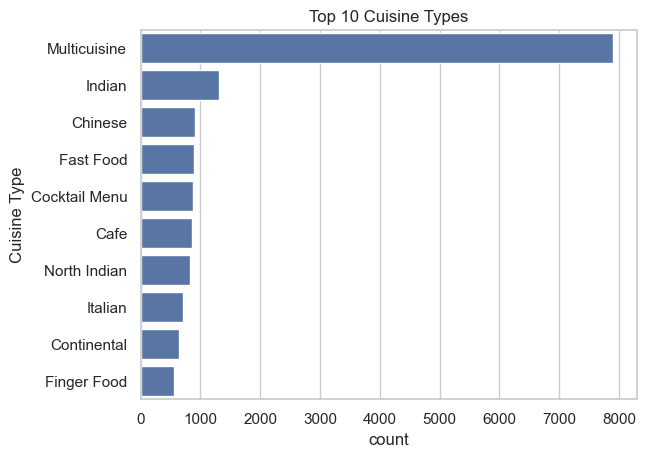

In [38]:
sns.countplot(
    data=df1.reset_index(drop=True),
    y='Cuisine Type',
    order=df1['Cuisine Type'].value_counts().head(10).index
)
plt.title("Top 10 Cuisine Types")
plt.show()

#### Count Plot (Top 10 Cities)

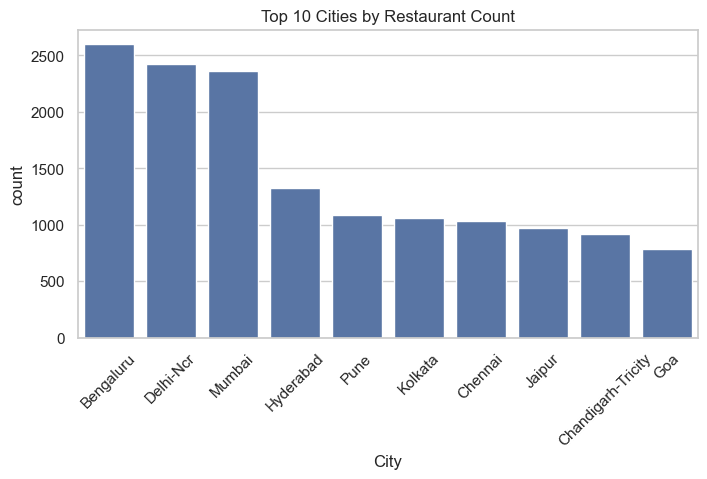

In [39]:
plt.figure(figsize=(8,4))
sns.countplot(data=df1.reset_index(drop=True), x="City", order=df1["City"].value_counts().index[:10])
plt.xticks(rotation=45)
plt.title("Top 10 Cities by Restaurant Count")
plt.show()

#### Pie Chart (City Distribution)

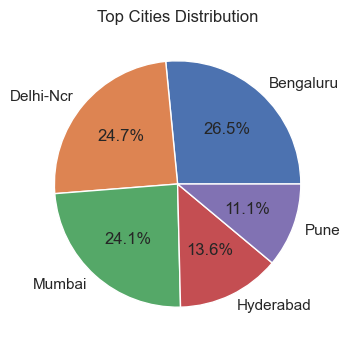

In [40]:
df1['City'].value_counts().head(5).plot.pie(autopct='%1.1f%%', figsize=(8,4))
plt.title("Top Cities Distribution")
plt.ylabel("")
plt.show()

### BIVARIATE

# **Bivariate Vizual Analysis:**


1.   Numerical vs Numerical
2.   Categorical vs Categorical
3.   Numerical vs Categorical

**1. Numerical vs Numerical:**  

      *   Scatter Plot
      *   Joint Plot

**2. Categorica vs Categorical:**

      *   Count Plot

**3. Numerical vs Categorical:**



      *   Bar Plot
      *   Box Plot
      *   Violin Plot
      *   Displot





#### Numerical - Numerical (Cost for Two vs Ratings)

In [41]:
# Correlation
df1[['Cost for Two', 'Ratings']].corr()

,Cost for Two,Ratings
Cost for Two,1.000000,0.074043
Ratings,0.074043,1.000000


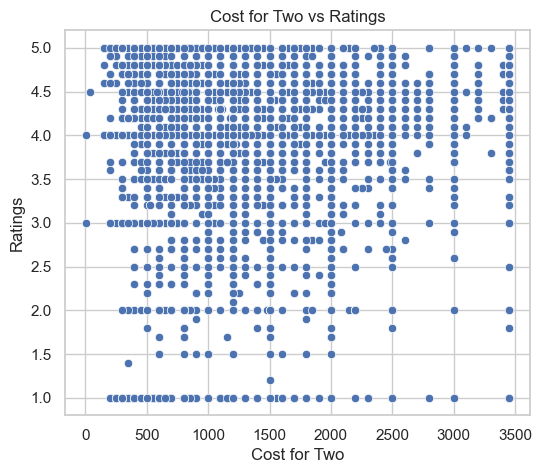

In [42]:
# Scatter plot
plt.figure(figsize=(6,5))
sns.scatterplot(data=df1, x='Cost for Two', y='Ratings')
plt.title("Cost for Two vs Ratings")
plt.show()


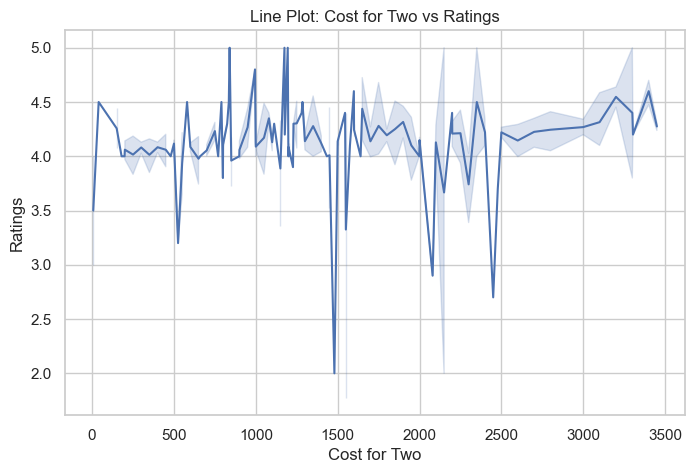

In [43]:
df_sorted = df1.sort_values('Cost for Two')

plt.figure(figsize=(8,5))
sns.lineplot(data=df_sorted, x='Cost for Two', y='Ratings')
plt.title("Line Plot: Cost for Two vs Ratings")
plt.xlabel("Cost for Two")
plt.ylabel("Ratings")
plt.show()

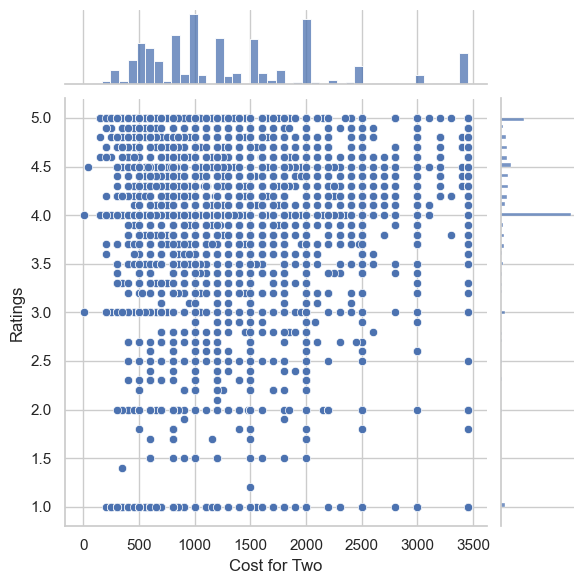

In [44]:
sns.jointplot(
    data=df1,
    x='Cost for Two',
    y='Ratings'
)
plt.show()

### Numerical ↔ Categorical

In [45]:
### Numerical to Categorical
# Average Cost by city
df1.groupby('City')['Cost for Two'].mean().sort_values(ascending=False)

City
Abu-Dhabi             3450.000000
Dubai                 3450.000000
Bengaluru             1779.965358
Delhi-Ncr             1445.878462
Mumbai                1362.919983
Udaipur               1281.730769
Goa                   1246.739130
Pune                  1211.892890
Chennai               1187.670862
Nagpur                1184.121622
Ludhiana              1182.163743
Hyderabad             1146.736247
Visakhapatnam         1144.964029
Jaipur                1144.684592
Agra                  1132.592593
Amritsar              1093.846154
Kolkata               1089.846081
Kochi                 1071.955556
Bhubaneswar           1055.123967
Chandigarh-Tricity    1034.858388
Mysuru                 985.087719
Ranchi                 981.930693
Ahmedabad              968.607372
Indore                 967.627907
Coimbatore             947.450980
Thiruvananthapuram     927.551020
Madurai                878.333333
Lucknow                866.314286
Vadodara               798.423423
Patna    

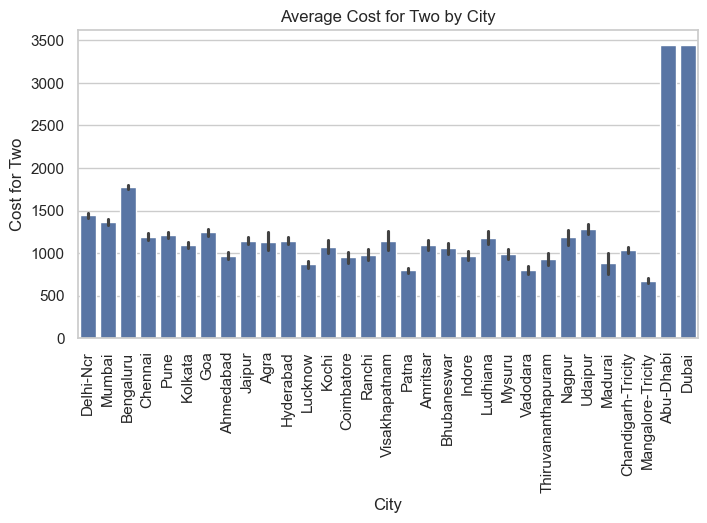

In [46]:
plt.figure(figsize=(8,4))
sns.barplot(data=df1, x='City', y='Cost for Two')
plt.title("Average Cost for Two by City")
plt.xticks(rotation=90)
plt.show()


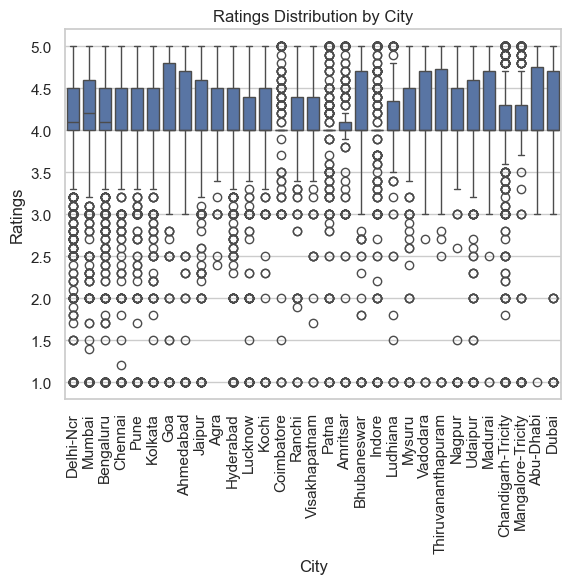

In [47]:
sns.boxplot(data=df1, x='City', y='Ratings')
plt.title("Ratings Distribution by City")
plt.xticks(rotation=90)
plt.show()

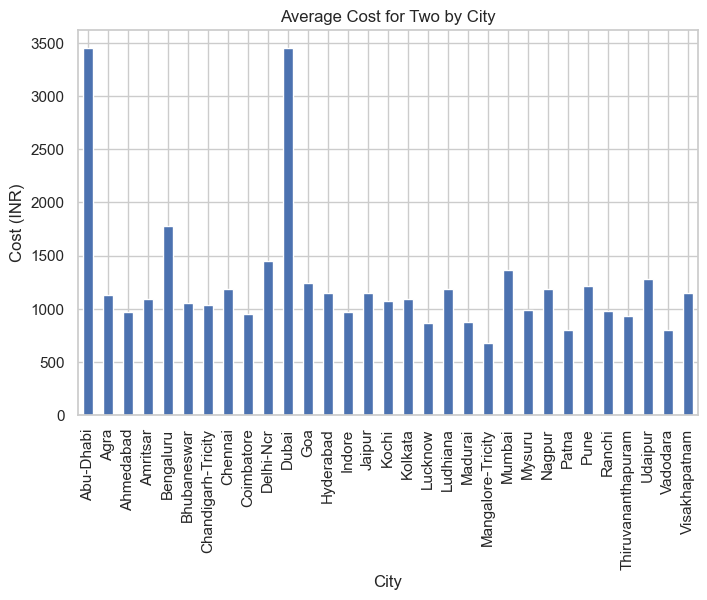

In [48]:
df1.groupby('City')['Cost for Two'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Cost for Two by City")
plt.ylabel("Cost (INR)")
plt.show()

### Categorical - Categorical

In [76]:
pd.crosstab(df1['Cuisine Type'], df1['City']).iloc[:16,:16]

City,Abu-Dhabi,Agra,Ahmedabad,Amritsar,Bengaluru,Bhubaneswar,Chandigarh-Tricity,Chennai,Coimbatore,Delhi-Ncr,Dubai,Goa,Hyderabad,Indore,Jaipur,Kochi
Cuisine Type,,,,,,,,,,,,,,,,
Afghani,0,0,1,0,1,0,0,0,0,1,3,0,1,0,0,0
African,0,0,0,0,1,0,2,0,0,2,4,0,0,0,0,0
All Day Dining,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,1
American,0,0,7,2,21,0,13,6,0,9,12,1,5,3,0,4
Andhra,0,0,0,0,16,0,0,5,0,0,0,0,10,1,0,1
Arabian,0,0,0,0,12,0,0,1,1,0,22,0,18,0,0,2
Asian,1,1,9,0,33,1,3,11,3,41,8,9,23,3,4,5
Awadhi,0,2,0,0,5,0,1,0,0,3,0,0,2,0,0,0
Bakery,0,2,13,3,45,8,10,14,3,36,2,11,22,4,16,7


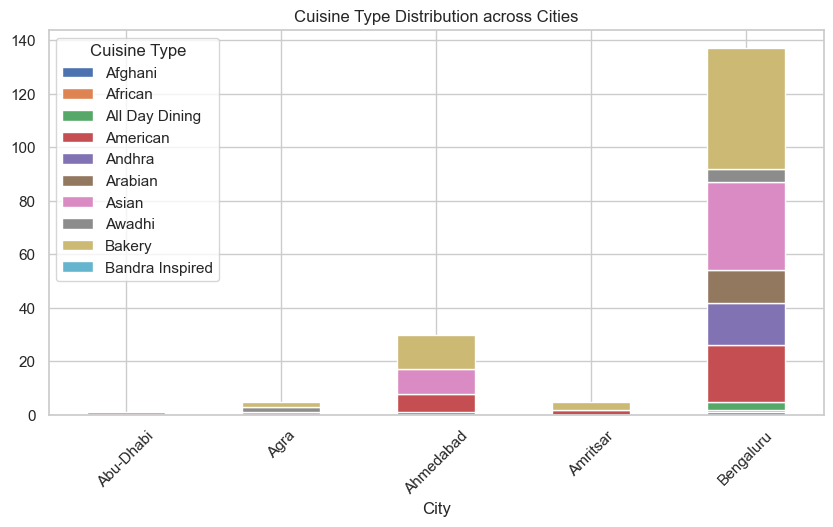

In [77]:
pd.crosstab(df1['City'], df1['Cuisine Type']).iloc[:, :10].head(5).plot(
    kind='bar',
    stacked=True,
    figsize=(10,5),
    
)

plt.title("Cuisine Type Distribution across Cities")
# plt.legend().set_visible(False)
plt.xticks(rotation=45)
plt.show()


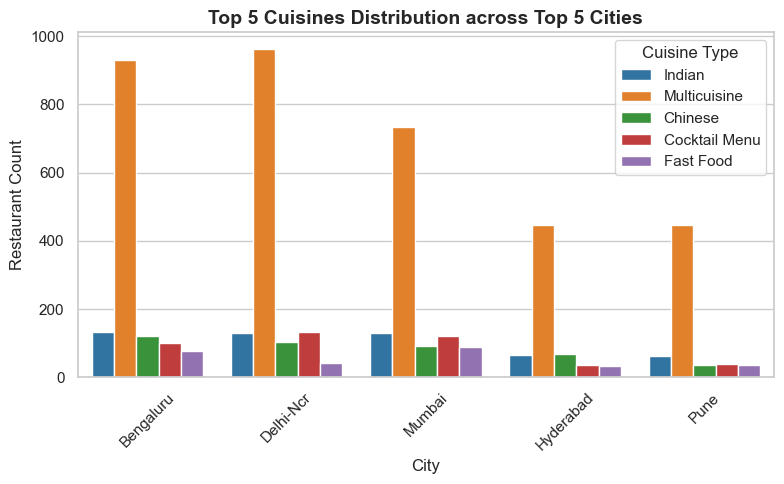

In [51]:
top_cities = df1["City"].value_counts().index[:10]
top_cuisines = df1['Cuisine Type'].value_counts().index[:5]
# filtered_df = df1[df1['Cuisine Type'].isin(top_cuisines)]
filtered_df = df1[df1["City"].isin(top_cities) & df1["Cuisine Type"].isin(top_cuisines)]

plt.figure(figsize=(8,5))

sns.countplot(
    data=filtered_df.reset_index(drop=True),
    x='City',
    hue='Cuisine Type',  # differentiate cuisines
    order=df1['City'].value_counts().head(5).index,
    palette='tab10'
)
plt.title("Top 5 Cuisines Distribution across Top 5 Cities", fontsize=14, weight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Restaurant Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



#### Categorical - Categorical

#### Pivot Table (City × Cuisine)

In [52]:
import pandas as pd

# Crosstab with mean Ratings
crosstab_ratings = pd.crosstab(
    index=df1['Cuisine Type'],  # rows
    columns=df1['City'],        # columns
    values=df1['Ratings'],      # numeric values to aggregate
    aggfunc='mean'              # aggregation function
)

crosstab_ratings


City,Abu-Dhabi,Agra,Ahmedabad,Amritsar,Bengaluru,Bhubaneswar,Chandigarh-Tricity,Chennai,Coimbatore,Delhi-Ncr,...,Mumbai,Mysuru,Nagpur,Patna,Pune,Ranchi,Thiruvananthapuram,Udaipur,Vadodara,Visakhapatnam
Cuisine Type,,,,,,,,,,,,,,,,,,,,,
Afghani,NaN,NaN,4.300000,NaN,4.200000,NaN,NaN,NaN,NaN,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
African,NaN,NaN,NaN,NaN,4.300000,NaN,4.600000,NaN,NaN,4.200000,...,4.566667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
All Day Dining,NaN,NaN,NaN,NaN,4.333333,NaN,NaN,NaN,NaN,NaN,...,4.600000,NaN,NaN,NaN,4.062500,NaN,NaN,NaN,NaN,NaN
American,NaN,NaN,4.457143,3.9,4.261905,NaN,4.023077,4.100000,NaN,4.233333,...,4.280000,3.333333,4.0,5.0,4.520000,4.0,4.7,4.1,NaN,4.00
Andhra,NaN,NaN,NaN,NaN,4.106250,NaN,NaN,4.360000,NaN,NaN,...,NaN,3.733333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uzbek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vegan,NaN,NaN,NaN,NaN,NaN,NaN,4.200000,5.000000,NaN,4.433333,...,4.000000,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,NaN
Vietnamese,NaN,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,4.600000,...,4.400000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,NaN


In [53]:
# Convert to string (handles NaN or list-like entries)
df1['Cuisine Type'] = df1['Cuisine Type'].astype(str)

# Remove brackets, quotes, and backslashes
df1['Cuisine Type'] = (
    df1['Cuisine Type']
    .str.replace(r"[\[\]'\"\\]", '', regex=True) # remove [ ] ' " \
    .str.strip()
)
df1['Cuisine Type'] = df1['Cuisine Type'].apply(lambda x: [i.strip() for i in x.split(',') if i.strip() != ''])

# Explode the list to create one row per cuisine
df1 = df1.explode('Cuisine Type')

# Now build pivot table safely
pivot_table = pd.pivot_table(
    df1,
    values='Ratings',
    index='Cuisine Type',
    columns='City',
    aggfunc='mean'
)
pivot_table

City,Abu-Dhabi,Agra,Ahmedabad,Amritsar,Bengaluru,Bhubaneswar,Chandigarh-Tricity,Chennai,Coimbatore,Delhi-Ncr,...,Mumbai,Mysuru,Nagpur,Patna,Pune,Ranchi,Thiruvananthapuram,Udaipur,Vadodara,Visakhapatnam
Cuisine Type,,,,,,,,,,,,,,,,,,,,,
Afghani,NaN,NaN,4.300000,NaN,4.200000,NaN,NaN,NaN,NaN,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
African,NaN,NaN,NaN,NaN,4.300000,NaN,4.600000,NaN,NaN,4.200000,...,4.566667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
All Day Dining,NaN,NaN,NaN,NaN,4.333333,NaN,NaN,NaN,NaN,NaN,...,4.600000,NaN,NaN,NaN,4.062500,NaN,NaN,NaN,NaN,NaN
American,NaN,NaN,4.457143,3.9,4.261905,NaN,4.023077,4.100000,NaN,4.233333,...,4.280000,3.333333,4.0,5.0,4.520000,4.0,4.7,4.1,NaN,4.00
Andhra,NaN,NaN,NaN,NaN,4.106250,NaN,NaN,4.360000,NaN,NaN,...,NaN,3.733333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uzbek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vegan,NaN,NaN,NaN,NaN,NaN,NaN,4.200000,5.000000,NaN,4.433333,...,4.000000,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,NaN
Vietnamese,NaN,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,4.600000,...,4.400000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,NaN


#### Continuous vs Continuous (Correlation)

In [54]:
df1[['Cost for Two', 'Ratings']].corr()

,Cost for Two,Ratings
Cost for Two,1.000000,0.074043
Ratings,0.074043,1.000000


#### Scatter Plot (Cost vs Ratings)

### MULTIVARIATE ANALYSIS

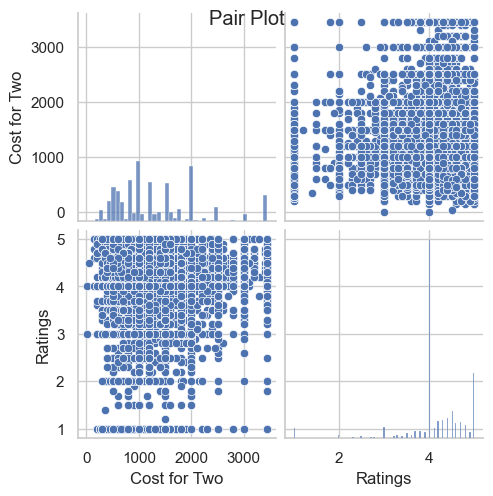

<Figure size 800x400 with 0 Axes>

In [55]:
sns.pairplot(df1[['Cost for Two', 'Ratings']])
plt.suptitle("Pair Plot")
plt.figure(figsize=(8,4))
plt.show()

#### Heatmap (Correlation Matrix)

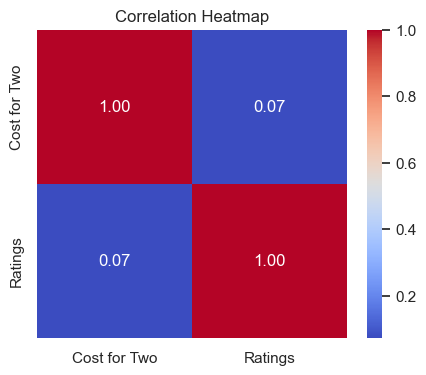

In [51]:
plt.figure(figsize=(5,4))
sns.heatmap(df1[['Cost for Two', 'Ratings']].corr(), annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()